<a href="https://colab.research.google.com/github/dJasawat/Guvi_Assignmnets5_AI-Powered-Banking-Support-Fraud-Intelligence-System-using-NLP-RAG/blob/main/AI_Banking_NLP_DataCleaning_and_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Load Required Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud


In [ ]:
#mount  Google drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
#Load Raw Data for Cleaning
DIR_PATH = "/content/drive/MyDrive/Guvi Projects/Guvi_Project5_NLP+RAG BankingSystem/"
df = pd.read_csv(DIR_PATH + "RawData/01_support_tickets.csv")


In [ ]:
rawData = df[["query_text", "category", "sentiment"]]
#display(rawData.head(20))
print("Categories : ", rawData["category"].unique())
print("Sentiments : ", rawData["sentiment"].unique())

Categories :  ['Fraud/Unauthorized' 'Loan' 'KYC' 'Account Access']
Sentiments :  ['Urgent' 'Neutral' 'Confused' 'Frustrated' 'Angry' 'Anxious']


In [ ]:
print(rawData["category"].value_counts())
print(rawData["sentiment"].value_counts())

category
Fraud/Unauthorized    50
Loan                  50
KYC                   50
Account Access        50
Name: count, dtype: int64
sentiment
Anxious       39
Confused      37
Urgent        33
Neutral       32
Frustrated    31
Angry         28
Name: count, dtype: int64


In [ ]:
rawData.duplicated().sum()

np.int64(52)

In [ ]:
#Data Preprocessing
import pickle
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
rawData['category'] = le.fit_transform(rawData['category'])

rawData

/tmp/ipykernel_959/1964873651.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rawData['category'] = le.fit_transform(rawData['category'])


,query_text,category,sentiment
0,I see a transaction of ₹999 I didn't make on 2...,1,Urgent
1,I see a transaction of ₹500 I didn't make on 1...,1,Neutral
2,"I see a transaction of ₹25,000 I didn't make o...",1,Neutral
3,I see a transaction of ₹999 I didn't make on 1...,1,Confused
4,"I see a transaction of ₹25,000 I didn't make o...",1,Frustrated
...,...,...,...
195,I can't see my recent transactions in the app,0,Neutral
196,I can't see my recent transactions in the app,0,Anxious
197,I can't see my recent transactions in the app,0,Neutral
198,I can't see my recent transactions in the app,0,Frustrated


In [ ]:
# Save Label Encoder
with open(DIR_PATH + "models/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

In [ ]:
rawData['category'].value_counts()

,count
category,
1,50
3,50
2,50
0,50


In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
def clean_data(text):
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Convert to lowercase
    text = text.lower()
    # Tokenize the text
    tokens = nltk.word_tokenize(text)
    # Remove stop words
    tokens = [word for word in tokens if word not in stop_words]
    # Lemmatization
    lemmatizer = nltk.WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

In [ ]:
#Clean Data
rawData['cleaned_query_text'] = rawData['query_text'].apply(clean_data)
cleanData = rawData.copy()

/tmp/ipykernel_959/481531452.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rawData['cleaned_query_text'] = rawData['query_text'].apply(clean_data)


In [ ]:
#Save the cleaned data to a new CSV file
rawData.to_csv(DIR_PATH + "ProcessedData/Cleaned_support_tickets.csv", index=False)

# **Create ML - Model **

In [ ]:
cleanData["category"] = le.inverse_transform(cleanData["category"])

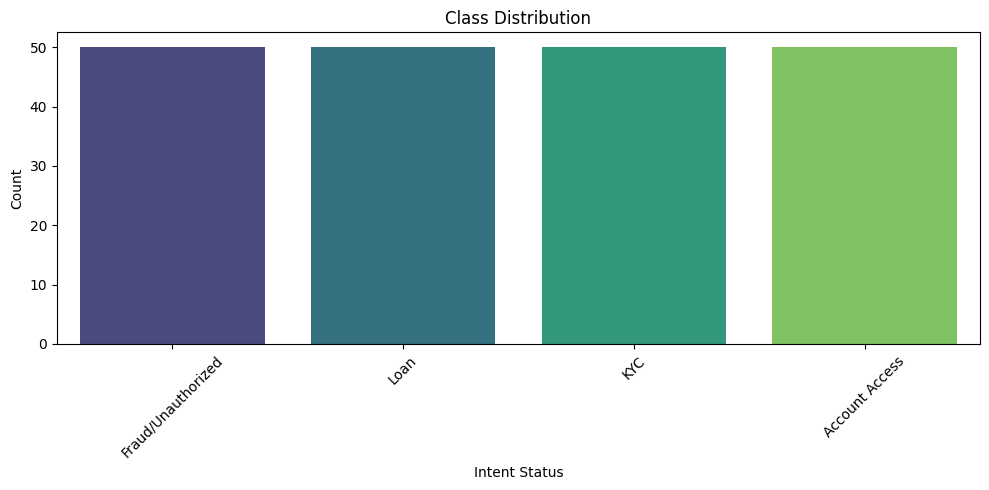

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=cleanData, x='category', order=cleanData['category'].value_counts().index,hue = "category", palette='viridis')
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
#Word Count per Query
rawData['word_count'] = rawData['cleaned_query_text'].apply(lambda x: len(x.split()))
rawData['word_count'].describe()

/tmp/ipykernel_959/210792676.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rawData['word_count'] = rawData['cleaned_query_text'].apply(lambda x: len(x.split()))


,word_count
count,200.000000
mean,5.325000
std,1.194365
min,3.000000
25%,4.750000
50%,5.000000
75%,6.000000
max,8.000000


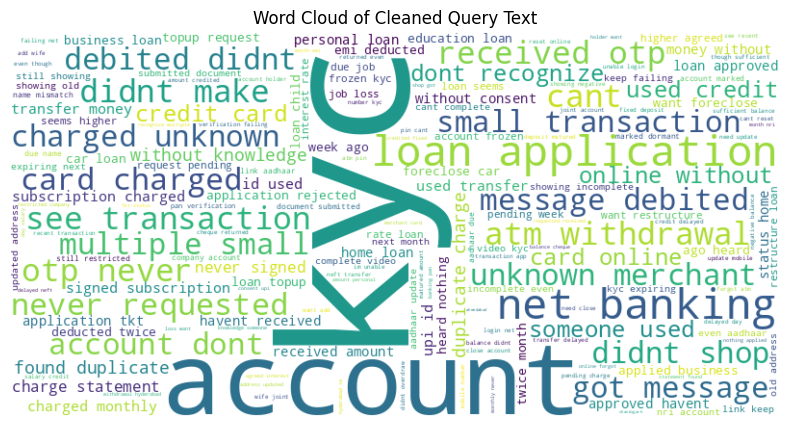

In [ ]:
#Generate a word cloud for the cleaned query text and display it
all_words = ' '.join([text for text in cleanData['cleaned_query_text']])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Cleaned Query Text")
plt.show()

In [ ]:
#generate word cloud for KYC category
kyc_words = ' '.join(cleanData[rawData['category'] == 'KYC']['cleaned_query_text'])
kyc_wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(kyc_words)
plt.figure(figsize=(10, 5))
plt.imshow(kyc_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of KYC Category")
plt.show()

ValueError: We need at least 1 word to plot a word cloud, got 0.

# **TF-IDF Vectorization and Model Training**


---



In [ ]:
#TF- IDF Vectorization and Model Training

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
# removed invalid import: from sklearn import BertClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [ ]:
#Split the data into training and testing sets
# Split data for Intent Classification
x_train, x_test, y_train, y_test = train_test_split(cleanData['cleaned_query_text'], cleanData['category'], stratify=cleanData['category'], test_size=0.2, random_state=42)
tfidf_vectorizer = TfidfVectorizer(max_features=200)
x_train_tfidf = tfidf_vectorizer.fit_transform(x_train)

In [ ]:
#Split the data into training and testing sets
# Split data for sentiment Classification
x_train_sentiment, x_test_sentiment, y_train_sentiment, y_test_sentiment = train_test_split(cleanData['cleaned_query_text'], cleanData['sentiment'], stratify=cleanData['sentiment'], test_size=0.2, random_state=42)
#tfidf_vectorizer = TfidfVectorizer(max_features=200)
x_train_sentiment_tfidf = tfidf_vectorizer.fit_transform(x_train_sentiment)

In [ ]:
def get_tuned_models():
    """
    Returns a dictionary of machine learning models with predefined hyperparameters.
    """
    tuned_models = {
        "Logistic Regression": LogisticRegression(random_state=42, solver='liblinear', max_iter=200),
        "LinearSVC": LinearSVC(random_state=42, C=0.5, max_iter=1000),
        "MultinomialNB": MultinomialNB(alpha=0.1), # Alpha is a smoothing parameter
        "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10, min_samples_leaf=5),
        # BertClassifier is not a standard sklearn module and its integration for hyperparameter tuning
        # would require a specific library (e.g., HuggingFace transformers) and different tuning strategies.
        # It's commented out to avoid errors unless a proper implementation is provided.
        # "BertClassifier": BertClassifier()
    }
    return tuned_models

In [ ]:
#Train Data  on multiple Models


In [ ]:
def train_evaluate_model(tuned_models, x_train, x_test, y_train, y_test):
    """
    Trains each model in the dictionary and returns evaluation results.
    """
    results = []

    for model_name, model in tuned_models.items():
        # Training
        model.fit(x_train, y_train)

        # Predictions
        y_pred = model.predict(x_test)

        # Metrics
        train_accuracy = model.score(x_train, y_train)
        # Fix: Set output_dict=True to return a dictionary instead of a string
        report = classification_report(y_test, y_pred, output_dict=True)

        results.append({
            'Model': model_name,
            'Train Accuracy': train_accuracy,
            'precision': report.get('weighted avg', {}).get('precision', 0),
            'recall': report.get('weighted avg', {}).get('recall', 0),
            'f1-score': report.get('weighted avg', {}).get('f1-score', 0)
        })

    return results

# 1. Vectorize the test set using the fitted vectorizer
x_test_tfidf = tfidf_vectorizer.transform(x_test)

# 2. Get the tuned models
tuned_models = get_tuned_models()

# 3. Train and Evaluate - Catgory Classification
evaluation_data_Intent = train_evaluate_model(tuned_models, x_train_tfidf, x_test_tfidf, y_train, y_test)

#4. Train and Evaluate - Sentiment Classification
evaluation_data_sentiment = train_evaluate_model(tuned_models, x_train_sentiment_tfidf, x_test_tfidf, y_train_sentiment, y_test_sentiment)

# 5. Display Results in a DataFrame
category_results_df = pd.DataFrame(evaluation_data_Intent)
category_results_df.set_index('Model', inplace=True)

display("Category Classification Model\n"+ category_results_df)

# 5 Display sentiment classification in dataframe
sentiment_results_df = pd.DataFrame(evaluation_data_sentiment)
sentiment_results_df.set_index('Model', inplace=True)

display("Sentiment Classification Model\n"+ sentiment_results_df)

,Train Accuracy,precision,recall,f1-score
Model,,,,
Logistic Regression,1.00,1.000000,1.000,1.000000
LinearSVC,1.00,1.000000,1.000,1.000000
MultinomialNB,1.00,1.000000,1.000,1.000000
Random Forest,0.95,0.897059,0.825,0.835512


In [ ]:
# Save all trained models to the specified directory in Google Drive
import os

# Ensure the models directory exists
models_dir = DIR_PATH + "models/"
if not os.path.exists(models_dir):
    os.makedirs(models_dir)

# Save each model in the tuned_models dictionary
for model_name, model in tuned_models.items():
    # Sanitize file name by replacing spaces with underscores
    file_name = f"{model_name.lower().replace(' ', '_')}_model.pkl"
    file_path = models_dir + file_name

    with open(file_path, 'wb') as f:
        pickle.dump(model, f)

    print(f"Successfully saved {model_name} to {file_path}")

Successfully saved Logistic Regression to /content/drive/MyDrive/Guvi Projects/Guvi_Project5_NLP+RAG BankingSystem/models/logistic_regression_model.pkl
Successfully saved LinearSVC to /content/drive/MyDrive/Guvi Projects/Guvi_Project5_NLP+RAG BankingSystem/models/linearsvc_model.pkl
Successfully saved MultinomialNB to /content/drive/MyDrive/Guvi Projects/Guvi_Project5_NLP+RAG BankingSystem/models/multinomialnb_model.pkl
Successfully saved Random Forest to /content/drive/MyDrive/Guvi Projects/Guvi_Project5_NLP+RAG BankingSystem/models/random_forest_model.pkl


In [ ]:
!pip install gradio -q

import gradio as gr

def predict_intent(user_query):
    # 1. Preprocess the input text
    cleaned_text = clean_data(user_query)

    # 2. Vectorize the cleaned text
    # Note: tfidf_vectorizer and tuned_models must be defined in previous cells
    vectorized_text = tfidf_vectorizer.transform([cleaned_text])

    # 3. Predict using the Logistic Regression model (highest performer)
    model = tuned_models['Logistic Regression']
    prediction = model.predict(vectorized_text)[0]

    # 4. Get confidence/probabilities
    probabilities = model.predict_proba(vectorized_text)[0]
    labels = model.classes_
    conf_dict = {labels[i]: float(probabilities[i]) for i in range(len(labels))}

    return prediction, conf_dict

# Define Gradio Interface
interface = gr.Interface(
    fn=predict_intent,
    inputs=gr.Textbox(lines=2, placeholder="Enter your banking query here...", label="Support Ticket Text"),
    outputs=[
        gr.Textbox(label="Predicted Category"),
        gr.Label(label="Confidence Scores")
    ],
    title="Banking Intent Classifier",
    description="Identify the category of a support ticket (e.g., KYC, Loan, Fraud, Account Access) based on the query text.",
    examples=[
        ["I see a transaction of 500 I didn't make"],
        ["How do I update my KYC documents?"],
        ["My education loan status is still pending."],
        ["I can't log into my net banking account."]
    ]
)

# Launch the app
interface.launch(debug=True, share=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://206a85947a16b5702f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
